In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [93]:
df = pd.read_csv('homework9/noisy_curvefit_data.csv')

In [94]:
df.shape
#100 rows,6 columns

(100, 6)

In [95]:
df.head(5)

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


In [96]:
df.tail(5)

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850


In [97]:
df.columns

Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')

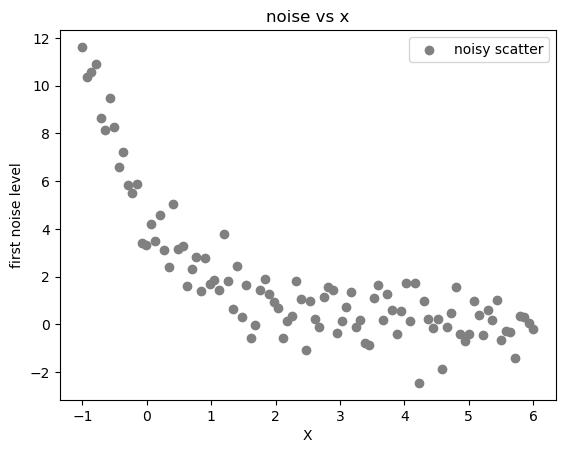

In [98]:
x=df['x']
y=df['y_noise_1']
plt.scatter(x,y,color = 'gray', label ="noisy scatter")
plt.xlabel("X")
plt.ylabel("first noise level")
plt.title("noise vs x")
plt.legend()
plt.show()


In [99]:
def model(x, A, k):
    return A * np.exp(-k * x)
p0 = [1, 1]
popt, pcov = curve_fit(model, x, y, p0=p0)

A_fit, k_fit = popt

print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Fit: y = 4.71 * e^(-0.92 * x)


In [100]:
residuals = y - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof
chi2_reduced

np.float64(0.7906732087457324)

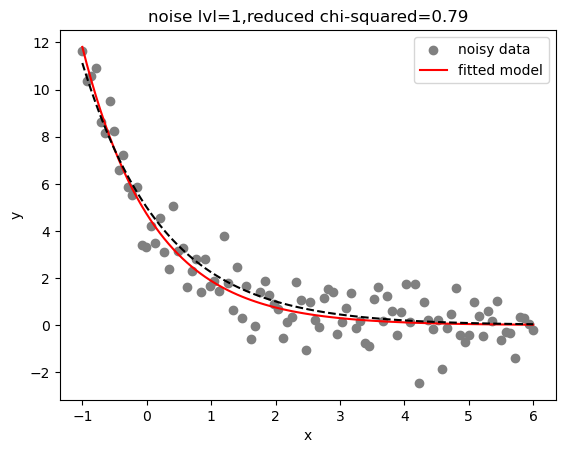

In [101]:
# • Scatter: noisy data
plt.scatter(x,y, label='noisy data', color = 'gray')
# • Red line: fitted model
plt.plot(x,model(x,A_fit,k_fit), color='red', label='fitted model')
        
# • Black dotted line: true model (use model(x, 5, 0.8))
plt.plot(x,model(x, 5, 0.8), color='black',linestyle="--")
# • Include the noise level (i.e., 1 since y noise 1) and reduced chi-squared in the title. Round
# the reduced chi-squared to two decimal places.
plt.title(f"noise lvl=1,reduced chi-squared={chi2_reduced:.2f}")
# Add axis labels and a legend
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


In [102]:
# Compare Different Noise Levels

def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt

    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof

    return A_fit, k_fit, chi2_reduced


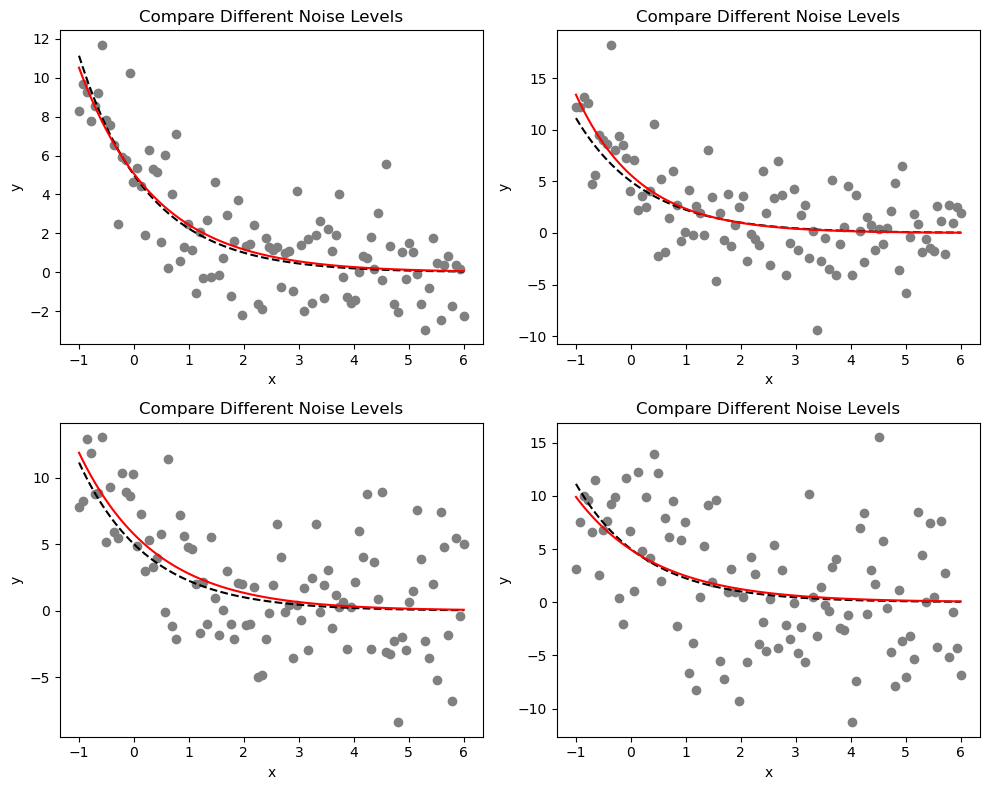

In [103]:
noise = [2, 3, 4, 5]
ycol  = [df[f"y_noise_{n}"].values for n in noise]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    y = ycol[i]
    A_fit, k_fit, chi2_reduced = fit_model(x, y)

    ax.scatter(x, y, color='gray', label="noisy scatter")
    ax.plot(x,model(x, 5, 0.8), color='black',linestyle="--",label='true model')
    ax.plot(x,model(x,A_fit,k_fit), color='red', label='fitted model')
    ax.set_title('Compare Different Noise Levels')
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

In [ ]:
# #  What happens to the red and black dotted lines as you increase the noise level?
# Why? drifted
# • What happens to the reduced chi-squared as you increase the noise level? Why

In [105]:
results=[]

for n in [1, 2, 3, 4, 5]:
    y = df[f"y_noise_{n}"].values
    A_fit, k_fit, chi2_reduced = fit_model(x, y)
    results.append({
        "noise_level":   n,
        "A_fit":          A_fit,
        "k_fit":          k_fit,
        "chi2_reduced":   chi2_reduced
    })


In [107]:
results_df = pd.DataFrame(results)
results_df

,noise_level,A_fit,k_fit,chi2_reduced
0,1,4.714814,0.918308,0.790673
1,2,5.063889,0.730396,3.649382
2,3,5.609396,0.870372,10.410207
3,4,5.738727,0.725965,12.626832
4,5,4.943458,0.695012,28.538124


In [108]:
results_df.to_csv("noisy_parameters.csv", index=False)
